# Phase 1: VPIN Insider Trading Validation on Polymarket

**Pre-registered hypotheses (frozen before data is loaded):**

| ID | Hypothesis | Test | Effect size | Minimum interesting effect |
|-----|-----------|------|-------------|---------------------------|
| H1 | VPIN is stochastically larger during insider-active windows | KS (alt='less') + Mann-Whitney + Permutation (10K) | KS D | D >= 0.15 |
| H2 | Signed flow at VPIN spikes predicts next price move during insider windows, not during non-insider windows | Binomial vs 0.5 | Cohen's h | Hit rate >= 60% (h >= 0.20) |
| H3 | VPIN leads price volatility when insiders active, not when absent | Cross-correlogram + bootstrap CI (1K) | Peak lag | Peak at lag >= +3 buckets |
| H4 | |ΔVPIN| spikes more sharply during insider entry than normal flow | KS on |ΔVPIN| insider vs non-insider | Max ΔVPIN ratio | 2x ratio |

**Multiple testing correction:** BH-FDR at q=0.10 (5 cases × 4 hypotheses × ~3 tests ≈ 60 tests).

**Decision criteria:**
- Strong positive (→ Phase 2): >= 3/5 cases show H1 significant after FDR AND KS D >= 0.15 AND hit rate >= 60%
- Weak positive (→ cautious Phase 2): 2/5 cases
- Negative (study ends): < 2 cases. Report honestly.

**KS convention note:** scipy `ks_2samp(a, b, alternative='less')` tests that `a` is stochastically LARGER than `b` (F_a(x) < F_b(x)). We use `alternative='less'` when testing insider > non-insider.

In [1]:
import sys
import gc
from pathlib import Path

_notebook_dir = Path(__file__).parent if "__file__" in dir() else Path.cwd()
_repo_root = str(_notebook_dir.parent) if _notebook_dir.name == "notebooks" else str(_notebook_dir)
if _repo_root not in sys.path:
    sys.path.insert(0, _repo_root)

import duckdb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

from src.analysis.util.vpin import vpin_cte
from src.analysis.util.normalization import polymarket_normalize_cte
from src.analysis.util.insider_cases import all_cases, CASES
from src.analysis.util.stats import (
    ks_test, mann_whitney_test, permutation_test,
    binomial_test, bootstrap_peak_lag, apply_bh_fdr,
)

rng = np.random.default_rng(seed=42)

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

# ── Print pre-registration contract ──
print("=== PRE-REGISTRATION CONTRACT ===")
print(f"Cases: {len(all_cases())}")
for c in all_cases():
    print(f"  {c.case_id}: {c.description} (${c.profit_usd:,.0f})")
print()
print("Hypotheses: H1 (distributional shift), H2 (directional accuracy),")
print("            H3 (lead-lag), H4 (ΔVPIN regime)")
print("FDR: BH at q=0.10")
print("Seed: 42")

=== PRE-REGISTRATION CONTRACT ===
Cases: 5
  ricosuave666: IDF reservist traded on Israel/Iran strike foreknowledge (Operation Rising Lion) ($152,300)
  0xafee_google: Trader correctly predicted 22/23 Google Year in Search terms (d4vd #1 searched) ($1,000,000)
  nobel_2025: Nobel Peace Prize 2025 leak — Machado winner known before announcement ($90,000)
  sb_halftime: Day-old account correctly predicted 17/20 Super Bowl LX halftime performers ($17,000)
  maduro_capture: New account traded hours before classified US raid on Maduro (Operation Absolute Resolve) ($436,000)

Hypotheses: H1 (distributional shift), H2 (directional accuracy),
            H3 (lead-lag), H4 (ΔVPIN regime)
FDR: BH at q=0.10
Seed: 42


## Cell 2: Data Acquisition

For each insider case, load Polymarket trades from parquet (or fetch via blockchain indexer).
Apply `polymarket_normalize_cte()` to produce the common schema.

**Data quality checks:** monotonic timestamps, no nulls, price in [0,100], no duplicate trade IDs.

In [2]:
# ── Configuration ──
REPO_ROOT = Path(_repo_root)
POLYMARKET_TRADES_DIR = REPO_ROOT / "data" / "polymarket" / "trades"
POLYMARKET_BLOCKS_DIR = REPO_ROOT / "data" / "polymarket" / "blocks"
POLYMARKET_MARKETS_DIR = REPO_ROOT / "data" / "polymarket" / "markets"
CACHE_DIR = REPO_ROOT / "data" / "case_study" / "phase1"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

BUCKET_SIZE = 200
LOOKBACK = 10
# Insider window: last N% of volume buckets (used when exact timestamps unknown)
INSIDER_WINDOW_PCT = 0.20

con = duckdb.connect()

# ── Load and normalize trades for each case ──
case_trades = {}  # case_id -> normalized trades DataFrame
case_summaries = []

for case in all_cases():
    cache_path = CACHE_DIR / f"{case.case_id}_normalized_trades.parquet"

    if cache_path.exists():
        df = pd.read_parquet(cache_path)
        print(f"  {case.case_id}: loaded {len(df):,} normalized trades from cache")
    else:
        # TODO: Fetch from blockchain indexer or load from raw parquet
        # For now, check if raw trades exist in the standard location
        raw_path = POLYMARKET_TRADES_DIR
        if not raw_path.exists():
            print(f"  {case.case_id}: SKIPPED — no Polymarket trade data found at {raw_path}")
            print(f"    Run the Polymarket trades indexer first, or place parquet files in {raw_path}")
            continue

        # Try to load and normalize
        try:
            # This requires raw blockchain trades + blocks + markets parquet files
            trades_glob = f"'{raw_path}/*.parquet'"
            blocks_glob = f"'{POLYMARKET_BLOCKS_DIR}/*.parquet'"
            markets_glob = f"'{POLYMARKET_MARKETS_DIR}/*.parquet'"

            cte = polymarket_normalize_cte(
                f"read_parquet({trades_glob})",
                f"read_parquet({blocks_glob})",
                f"read_parquet({markets_glob})",
            )
            df = con.execute(f"""
                WITH {cte}
                SELECT * FROM trades
                WHERE ticker = '{case.condition_id}'
                ORDER BY created_time
            """).df()

            if len(df) == 0:
                print(f"  {case.case_id}: SKIPPED — no trades found for condition_id={case.condition_id}")
                continue

            df.to_parquet(cache_path, index=False)
            print(f"  {case.case_id}: normalized and cached {len(df):,} trades")
        except Exception as e:
            print(f"  {case.case_id}: ERROR — {e}")
            continue

    case_trades[case.case_id] = df

    # Data quality checks
    ts = pd.to_datetime(df["created_time"])
    checks = {
        "monotonic_timestamps": ts.is_monotonic_increasing,
        "no_null_timestamps": ts.notna().all(),
        "no_null_sides": df["taker_side"].notna().all(),
        "no_null_prices": df["yes_price"].notna().all(),
        "prices_in_range": (df["yes_price"] >= 0).all() and (df["yes_price"] <= 100).all(),
    }
    failed = [k for k, v in checks.items() if not v]
    if failed:
        print(f"    WARNING: quality checks failed: {failed}")

    case_summaries.append({
        "Case": case.case_id,
        "Market": case.market_slug,
        "Trades": len(df),
        "Date range": f"{ts.min().date()} → {ts.max().date()}",
        "Volume": f"{df['count'].sum():,.0f}",
        "Profit": f"${case.profit_usd:,.0f}",
        "Evidence": case.evidence_strength,
        "Quality": "PASS" if not failed else f"FAIL: {failed}",
    })

if case_summaries:
    display(pd.DataFrame(case_summaries))
else:
    print("\nNo case data loaded. Populate data/polymarket/ directories first.")
    print("See README for indexer instructions.")

  ricosuave666: loaded 2,146 normalized trades from cache
  0xafee_google: loaded 390 normalized trades from cache


  nobel_2025: loaded 3,500 normalized trades from cache
  sb_halftime: loaded 3,321 normalized trades from cache
  maduro_capture: loaded 3,500 normalized trades from cache


,Case,Market,Trades,Date range,Volume,Profit,Evidence,Quality
0,ricosuave666,israel-military-action-against-iran-by-friday-477,2146,2025-06-11 → 2025-06-13,"3,937,291","$152,300",strong,PASS
1,0xafee_google,will-d4vd-rank-in-googles-top-5-most-searched-...,390,2025-11-20 → 2025-12-04,"166,022","$1,000,000",strong,PASS
2,nobel_2025,will-mara-corina-machado-win-the-nobel-peace-p...,3500,2025-09-27 → 2025-10-10,"2,108,149","$90,000",strong,PASS
3,sb_halftime,will-lady-gaga-perform-during-the-super-bowl-l...,3321,2026-02-06 → 2026-02-09,"656,924","$17,000",moderate,PASS
4,maduro_capture,maduro-out-by-january-31-2026-318,3500,2026-01-03 → 2026-01-03,"7,021,504","$436,000",strong,PASS


## Cell 3: VPIN Computation

Run `vpin_cte()` on normalized trades for each case. Includes `delta_vpin` column.

In [3]:
case_vpins = {}  # case_id -> VPIN DataFrame

MIN_NON_INSIDER_BUCKETS = 10  # Minimum control group size

for case_id, trades_df in case_trades.items():
    case = CASES[case_id]
    table_name = f"trades_{case_id}"
    con.register(table_name, trades_df)

    vpin_df = con.execute(f"""
        WITH {vpin_cte(table_name, BUCKET_SIZE, LOOKBACK)}
        SELECT * FROM vpin_series
        WHERE window_size = {LOOKBACK}
        ORDER BY bucket_id
    """).df()

    case_vpins[case_id] = vpin_df

    # Define insider-active window
    n_buckets = len(vpin_df)
    # Default: percentage-based (last 20%)
    insider_start_bucket = int(n_buckets * (1 - INSIDER_WINDOW_PCT))
    split_method = "percentage"

    # If we have exact timestamps, try them — but fall back if split is too extreme
    if case.insider_window_start and case.insider_window_end:
        ts = pd.to_datetime(vpin_df["bucket_end"])
        insider_mask = (
            (ts >= case.insider_window_start) &
            (ts <= case.insider_window_end)
        )
        if insider_mask.sum() > 0:
            candidate_start = vpin_df.index[insider_mask].min()
            non_insider_count = candidate_start
            if non_insider_count >= MIN_NON_INSIDER_BUCKETS:
                insider_start_bucket = candidate_start
                split_method = "timestamp"
            else:
                # Data doesn't extend far enough before insider window;
                # fall back to percentage-based split
                split_method = f"percentage (timestamp gave {non_insider_count} non-insider buckets)"

    vpin_df["is_insider_window"] = vpin_df.index >= insider_start_bucket

    insider_n = vpin_df["is_insider_window"].sum()
    non_insider_n = (~vpin_df["is_insider_window"]).sum()

    print(
        f"{case_id}: {n_buckets} VPIN buckets "
        f"(insider: {insider_n}, non-insider: {non_insider_n}), "
        f"split={split_method}, "
        f"VPIN range=[{vpin_df['vpin'].min():.3f}, {vpin_df['vpin'].max():.3f}]"
    )

print(f"\nCases with VPIN data: {len(case_vpins)}")

ricosuave666: 1347 VPIN buckets (insider: 270, non-insider: 1077), split=percentage (timestamp gave 0 non-insider buckets), VPIN range=[0.602, 1.000]
0xafee_google: 150 VPIN buckets (insider: 130, non-insider: 20), split=timestamp, VPIN range=[0.738, 1.000]
nobel_2025: 1478 VPIN buckets (insider: 1380, non-insider: 98), split=timestamp, VPIN range=[0.423, 1.000]
sb_halftime: 1121 VPIN buckets (insider: 1098, non-insider: 23), split=timestamp, VPIN range=[0.506, 1.000]
maduro_capture: 1555 VPIN buckets (insider: 311, non-insider: 1244), split=percentage (timestamp gave 0 non-insider buckets), VPIN range=[0.624, 1.000]

Cases with VPIN data: 5


## Cell 4: Experiment 1 — Within-Market Temporal Comparison (H1)

For each case: compare VPIN distribution in insider-active window vs prior equal-duration window.

Tests: KS (alternative='less' → insider stochastically larger), Mann-Whitney, Permutation (10K iter).

ricosuave666:
  Insider mean VPIN:     0.9566 (n=270)
  Non-insider mean VPIN: 0.9478 (n=1077)
  KS D=0.1719  p=2.3991e-06  SIG
  MW U=158285.5  p=1.2017e-02  SIG
  Perm diff=0.0088  p=0.0177

0xafee_google:
  Insider mean VPIN:     0.9255 (n=130)
  Non-insider mean VPIN: 0.9743 (n=20)
  KS D=0.1615  p=3.6917e-01  
  MW U=783.0  p=9.9789e-01  
  Perm diff=-0.0488  p=0.9998



nobel_2025:
  Insider mean VPIN:     0.9035 (n=1380)
  Non-insider mean VPIN: 0.7392 (n=98)
  KS D=0.5520  p=6.8866e-27  SIG
  MW U=109678.0  p=3.4247e-25  SIG
  Perm diff=0.1643  p=0.0000



sb_halftime:
  Insider mean VPIN:     0.8725 (n=1098)
  Non-insider mean VPIN: 0.9111 (n=23)
  KS D=0.0594  p=8.2062e-01  
  MW U=9340.5  p=9.8379e-01  
  Perm diff=-0.0386  p=0.9912



/workspace/.venv/lib/python3.9/site-packages/scipy/stats/_axis_nan_policy.py:531: RuntimeWarning: ks_2samp: Exact calculation unsuccessful. Switching to method=asymp.
  res = hypotest_fun_out(*samples, **kwds)


maduro_capture:
  Insider mean VPIN:     0.9737 (n=311)
  Non-insider mean VPIN: 0.8964 (n=1244)
  KS D=0.5659  p=3.9203e-70  SIG
  MW U=325991.0  p=1.8101e-78  SIG
  Perm diff=0.0774  p=0.0000



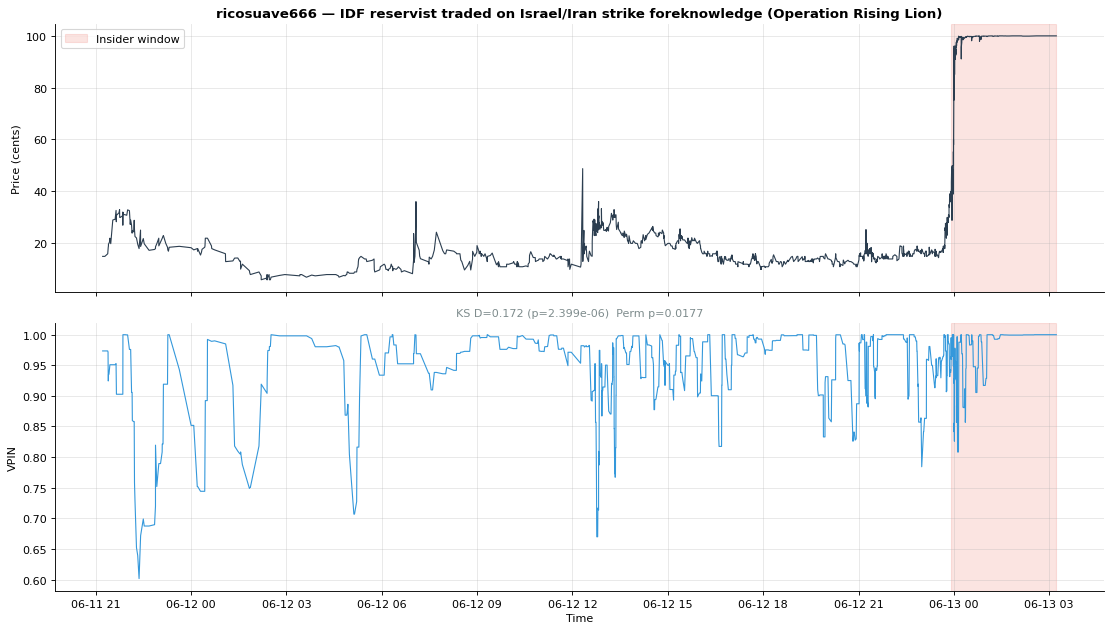

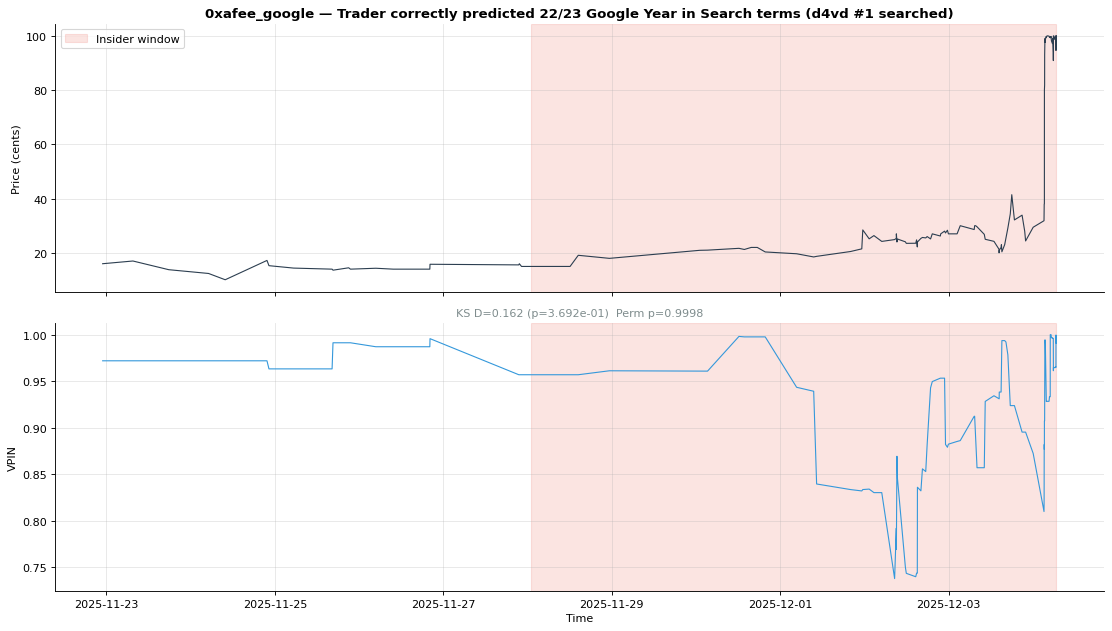

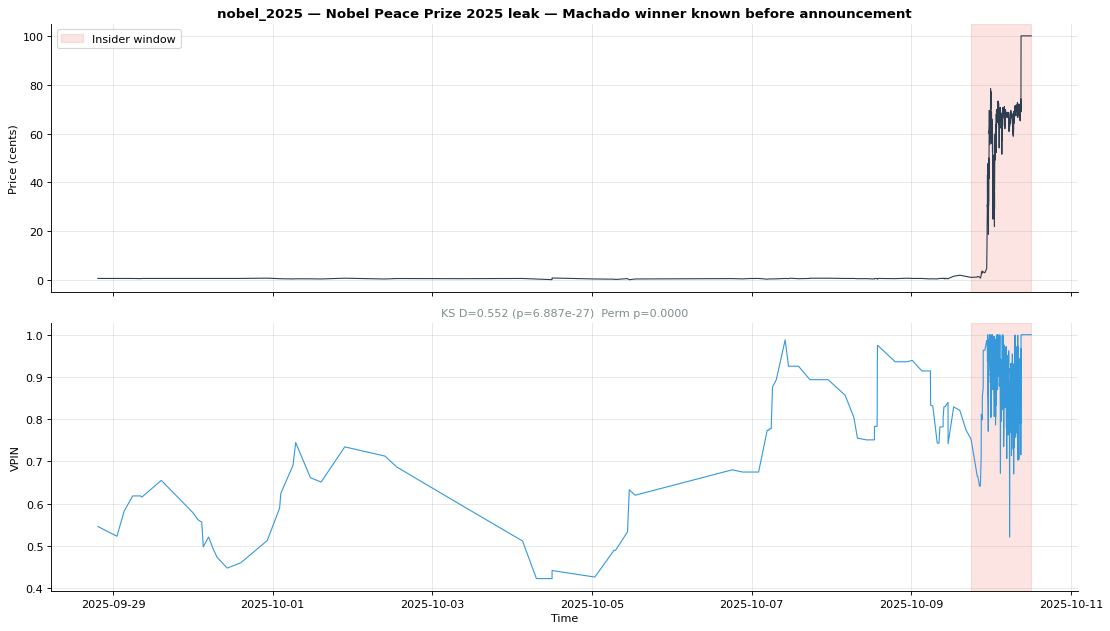

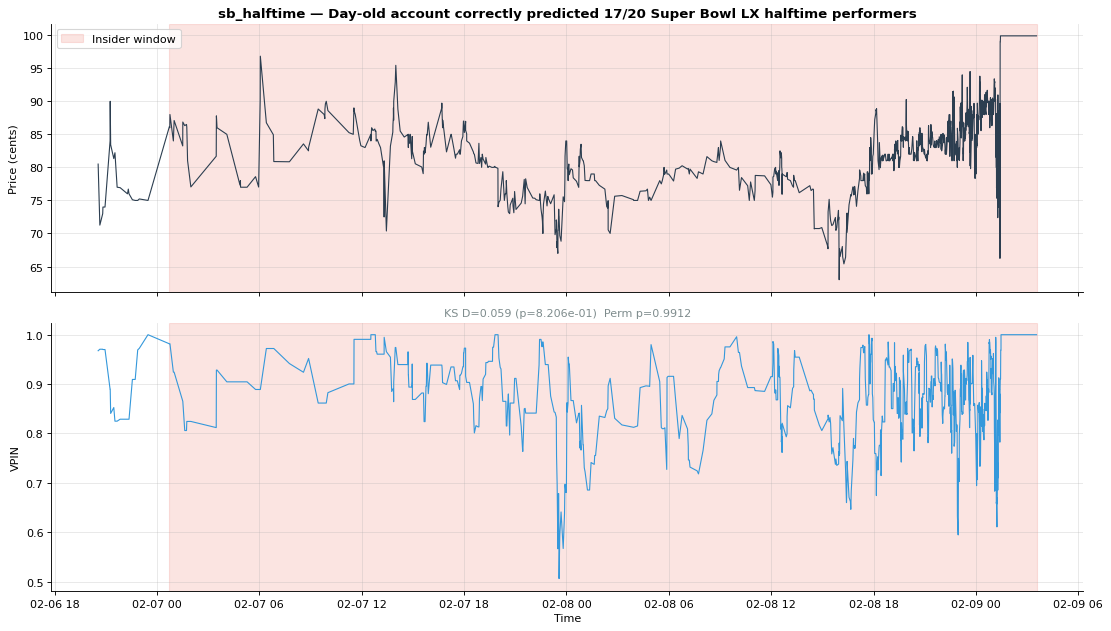

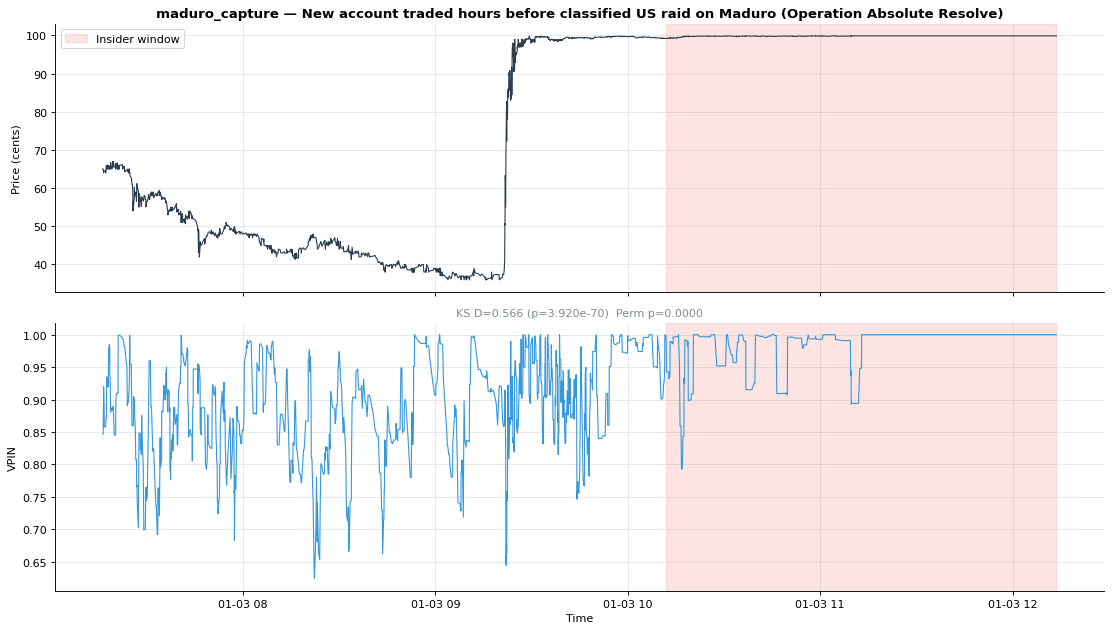

In [4]:
h1_results = {}  # case_id -> dict of test results
all_pvalues = []  # (case_id, hypothesis, test_name, p_value)

for case_id, vpin_df in case_vpins.items():
    insider = vpin_df[vpin_df["is_insider_window"]]["vpin"].values
    non_insider = vpin_df[~vpin_df["is_insider_window"]]["vpin"].values

    if len(insider) < 5 or len(non_insider) < 5:
        print(f"{case_id}: SKIPPED — insufficient data (insider={len(insider)}, non={len(non_insider)})")
        continue

    # KS test: insider stochastically larger → alternative='less' (F_insider < F_non)
    ks = ks_test(insider, non_insider, alternative="less")
    mw = mann_whitney_test(insider, non_insider, alternative="greater")
    perm = permutation_test(insider, non_insider, n_permutations=10_000, seed=42)

    h1_results[case_id] = {
        "ks": ks, "mw": mw, "perm": perm,
        "insider_mean": np.mean(insider),
        "non_insider_mean": np.mean(non_insider),
    }

    all_pvalues.append((case_id, "H1", "KS", ks.pvalue))
    all_pvalues.append((case_id, "H1", "MW", mw.pvalue))
    all_pvalues.append((case_id, "H1", "Perm", perm.pvalue))

    print(f"{case_id}:")
    print(f"  Insider mean VPIN:     {np.mean(insider):.4f} (n={len(insider)})")
    print(f"  Non-insider mean VPIN: {np.mean(non_insider):.4f} (n={len(non_insider)})")
    print(f"  KS D={ks.statistic:.4f}  p={ks.pvalue:.4e}  {'SIG' if ks.significant else ''}")
    print(f"  MW U={mw.statistic:.1f}  p={mw.pvalue:.4e}  {'SIG' if mw.significant else ''}")
    print(f"  Perm diff={perm.observed_stat:.4f}  p={perm.pvalue:.4f}")
    print()

# ── Timeline panels ──
for case_id, vpin_df in case_vpins.items():
    if case_id not in h1_results:
        continue

    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    time = pd.to_datetime(vpin_df["bucket_end"])
    insider_mask = vpin_df["is_insider_window"]

    # Price
    ax = axes[0]
    ax.plot(time, vpin_df["avg_price"], color="#2c3e50", linewidth=1)
    ax.axvspan(time[insider_mask].min(), time[insider_mask].max(),
               alpha=0.15, color="#e74c3c", label="Insider window")
    ax.set_ylabel("Price (cents)")
    ax.set_title(f"{case_id} — {CASES[case_id].description}", fontsize=12, fontweight="bold")
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

    # VPIN
    ax = axes[1]
    ax.plot(time, vpin_df["vpin"], color="#3498db", linewidth=1)
    ax.axvspan(time[insider_mask].min(), time[insider_mask].max(),
               alpha=0.15, color="#e74c3c")
    res = h1_results[case_id]
    ax.set_ylabel("VPIN")
    ax.set_xlabel("Time")
    ax.set_title(
        f"KS D={res['ks'].statistic:.3f} (p={res['ks'].pvalue:.3e})  "
        f"Perm p={res['perm'].pvalue:.4f}",
        fontsize=10, color="#7f8c8d",
    )
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Cell 5: Experiment 2 — ΔVPIN Regime Detection (H4)

Compare |ΔVPIN| distribution in insider-active vs non-active windows.
A sudden jump signals new information arrival — absolute VPIN may be high in noisy markets,
but a sudden *change* in VPIN is more specific to information events.

ricosuave666:
  Max |ΔVPIN| insider:     0.0970
  Max |ΔVPIN| non-insider: 0.1000
  Ratio: 0.97x  (threshold: 2x)
  KS D=0.0044  p=9.8845e-01

0xafee_google:
  Max |ΔVPIN| insider:     0.1000
  Max |ΔVPIN| non-insider: 0.0388
  Ratio: 2.58x  (threshold: 2x)
  KS D=0.2462  p=1.0533e-01

nobel_2025:
  Max |ΔVPIN| insider:     0.1000
  Max |ΔVPIN| non-insider: 0.0993
  Ratio: 1.01x  (threshold: 2x)
  KS D=0.0014  p=9.9835e-01

sb_halftime:
  Max |ΔVPIN| insider:     0.0991
  Max |ΔVPIN| non-insider: 0.0806
  Ratio: 1.23x  (threshold: 2x)
  KS D=0.2014  p=1.4054e-01

maduro_capture:
  Max |ΔVPIN| insider:     0.0911
  Max |ΔVPIN| non-insider: 0.1000
  Ratio: 0.91x  (threshold: 2x)
  KS D=0.0000  p=1.0000e+00



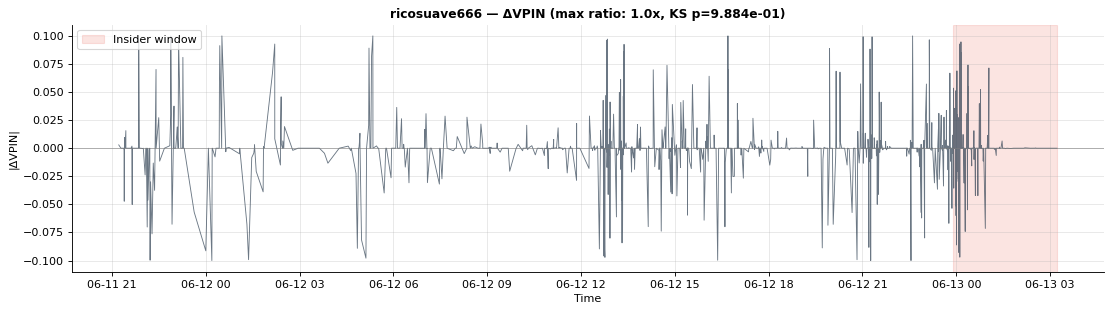

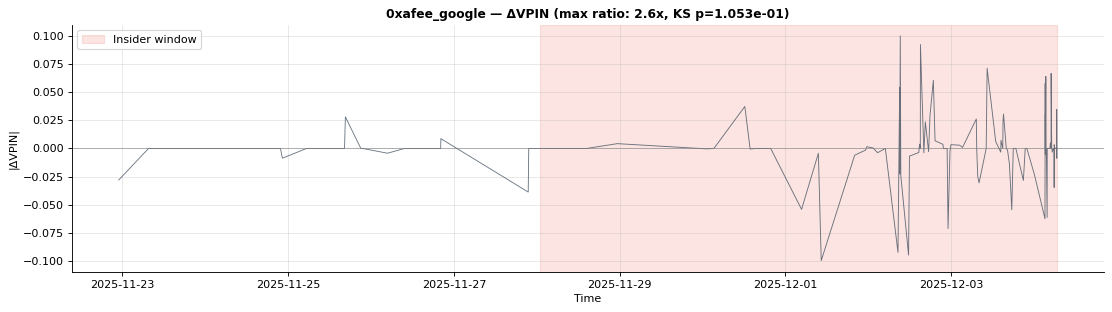

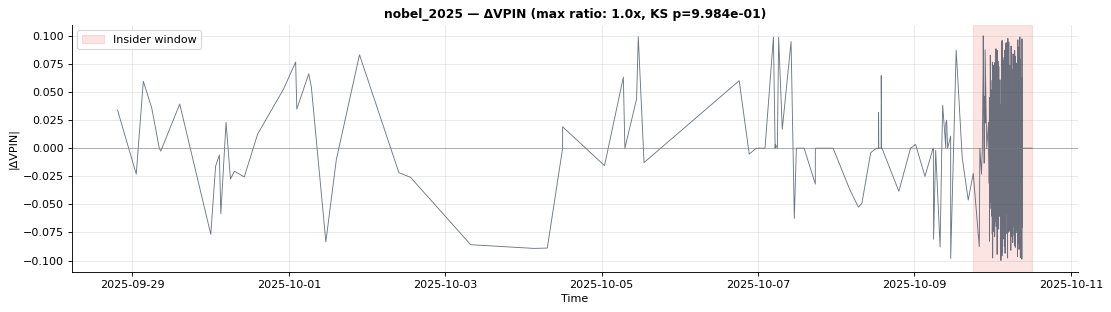

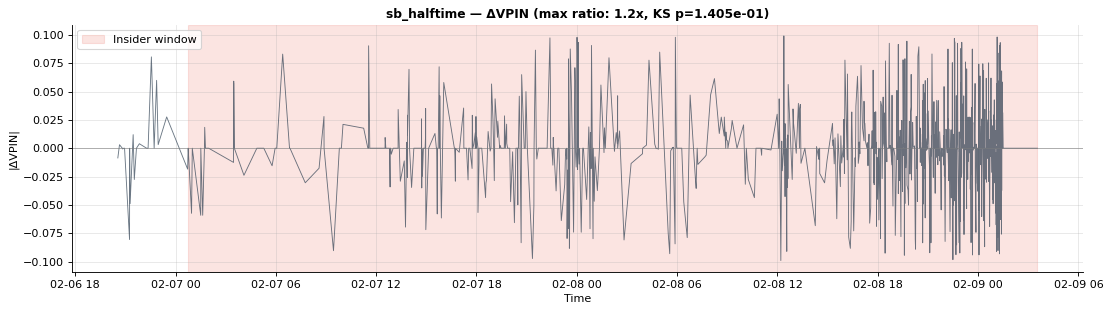

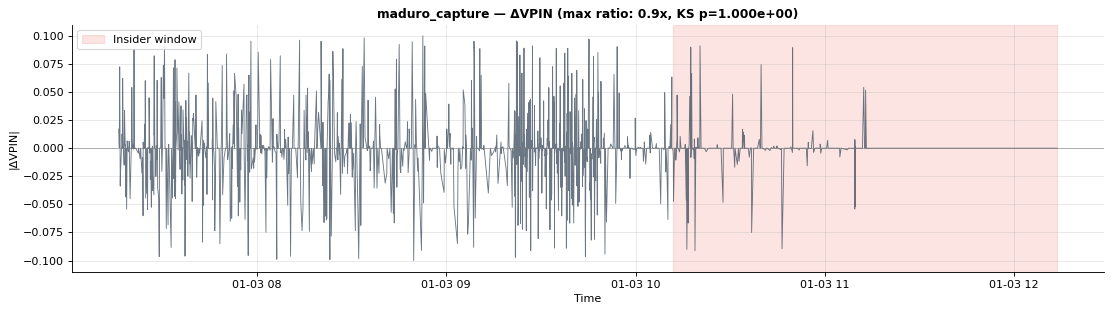

In [5]:
h4_results = {}

for case_id, vpin_df in case_vpins.items():
    delta = vpin_df["delta_vpin"].dropna()
    insider_mask = vpin_df.loc[delta.index, "is_insider_window"]

    abs_delta_insider = delta[insider_mask].abs().values
    abs_delta_non = delta[~insider_mask].abs().values

    if len(abs_delta_insider) < 3 or len(abs_delta_non) < 3:
        print(f"{case_id}: SKIPPED — insufficient ΔVPIN data")
        continue

    ks = ks_test(abs_delta_insider, abs_delta_non, alternative="less")
    max_ratio = (
        np.max(abs_delta_insider) / np.max(abs_delta_non)
        if np.max(abs_delta_non) > 0 else float("inf")
    )

    h4_results[case_id] = {
        "ks": ks,
        "max_delta_insider": np.max(abs_delta_insider),
        "max_delta_non": np.max(abs_delta_non),
        "max_ratio": max_ratio,
    }

    all_pvalues.append((case_id, "H4", "KS_delta", ks.pvalue))

    print(f"{case_id}:")
    print(f"  Max |ΔVPIN| insider:     {np.max(abs_delta_insider):.4f}")
    print(f"  Max |ΔVPIN| non-insider: {np.max(abs_delta_non):.4f}")
    print(f"  Ratio: {max_ratio:.2f}x  (threshold: 2x)")
    print(f"  KS D={ks.statistic:.4f}  p={ks.pvalue:.4e}")
    print()

# ── ΔVPIN time series plots ──
for case_id, vpin_df in case_vpins.items():
    if case_id not in h4_results:
        continue

    fig, ax = plt.subplots(figsize=(14, 4))
    time = pd.to_datetime(vpin_df["bucket_end"])
    delta = vpin_df["delta_vpin"]
    insider_mask = vpin_df["is_insider_window"]

    ax.plot(time, delta, color="#2c3e50", linewidth=0.8, alpha=0.7)
    ax.axvspan(time[insider_mask].min(), time[insider_mask].max(),
               alpha=0.15, color="#e74c3c", label="Insider window")
    ax.axhline(y=0, color="gray", linestyle="-", linewidth=0.5)
    ax.set_ylabel("|ΔVPIN|")
    ax.set_xlabel("Time")
    res = h4_results[case_id]
    ax.set_title(
        f"{case_id} — ΔVPIN (max ratio: {res['max_ratio']:.1f}x, KS p={res['ks'].pvalue:.3e})",
        fontsize=11, fontweight="bold",
    )
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Cell 6: Experiment 3 — Directional Accuracy (H2)

At VPIN spike timestamps (above market's own 90th percentile), measure whether signed_flow
direction predicts the subsequent price move. Compare hit rates for insider-active vs non-active windows.

In [6]:
FORWARD_K = 10  # Look ahead k buckets
h2_results = {}

for case_id, vpin_df in case_vpins.items():
    # Market-specific threshold (90th percentile of own VPIN)
    threshold = vpin_df["vpin"].quantile(0.90)
    spike_mask = vpin_df["vpin"] > threshold

    price = vpin_df["avg_price"].values
    signed = vpin_df["signed_flow"].values
    insider_mask = vpin_df["is_insider_window"].values

    # Compute hit rates for insider and non-insider windows
    for window_name, window_mask in [("insider", insider_mask), ("non_insider", ~insider_mask)]:
        combined = spike_mask.values & window_mask
        spike_indices = np.where(combined)[0]

        hits, total = 0, 0
        for idx in spike_indices:
            future = idx + FORWARD_K
            if future >= len(price):
                continue
            delta = price[future] - price[idx]
            if delta == 0:
                continue
            if np.sign(signed[idx]) == np.sign(delta):
                hits += 1
            total += 1

        if window_name == "insider":
            insider_hits, insider_total = hits, total
        else:
            non_hits, non_total = hits, total

    # Binomial tests
    if insider_total >= 3:
        binom_insider = binomial_test(insider_hits, insider_total)
        all_pvalues.append((case_id, "H2", "Binom_insider", binom_insider.pvalue))
    else:
        binom_insider = None

    if non_total >= 3:
        binom_non = binomial_test(non_hits, non_total)
    else:
        binom_non = None

    h2_results[case_id] = {
        "insider_hits": insider_hits, "insider_total": insider_total,
        "non_hits": non_hits, "non_total": non_total,
        "binom_insider": binom_insider, "binom_non": binom_non,
        "threshold": threshold,
    }

    insider_hr = insider_hits / insider_total if insider_total > 0 else float("nan")
    non_hr = non_hits / non_total if non_total > 0 else float("nan")

    print(f"{case_id} (threshold={threshold:.3f}):")
    print(f"  Insider:     {insider_hits}/{insider_total} = {insider_hr:.1%}"
          f"  {'(p=' + f'{binom_insider.pvalue:.4f})' if binom_insider else '(too few)'}")
    print(f"  Non-insider: {non_hits}/{non_total} = {non_hr:.1%}"
          f"  {'(p=' + f'{binom_non.pvalue:.4f})' if binom_non else '(too few)'}")
    if binom_insider:
        print(f"  Cohen's h (insider): {binom_insider.cohen_h:.3f}")
    print()

ricosuave666 (threshold=1.000):
  Insider:     0/0 = nan%  (too few)
  Non-insider: 0/0 = nan%  (too few)

0xafee_google (threshold=0.997):
  Insider:     4/11 = 36.4%  (p=0.8867)
  Non-insider: 0/0 = nan%  (too few)
  Cohen's h (insider): -0.276

nobel_2025 (threshold=0.995):
  Insider:     51/99 = 51.5%  (p=0.4204)
  Non-insider: 0/0 = nan%  (too few)
  Cohen's h (insider): 0.030

sb_halftime (threshold=0.973):
  Insider:     40/90 = 44.4%  (p=0.8769)
  Non-insider: 0/1 = 0.0%  (too few)
  Cohen's h (insider): -0.111

maduro_capture (threshold=0.998):
  Insider:     21/39 = 53.8%  (p=0.3746)
  Non-insider: 26/44 = 59.1%  (p=0.1456)
  Cohen's h (insider): 0.077



## Cell 7: Experiment 4 — Lead-Lag (H3)

Cross-correlogram of VPIN vs |Δprice| in insider-active vs non-active windows.
Bootstrap CI for peak lag location.

ricosuave666 (insider): peak lag = -12  CI=[-20, -4]
ricosuave666 (non_insider): peak lag = -17  CI=[-20, 5]



/workspace/src/analysis/util/stats.py:255: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, _ = sp_stats.pearsonr(xi, yi)


/workspace/src/analysis/util/stats.py:255: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, _ = sp_stats.pearsonr(xi, yi)


0xafee_google (insider): peak lag = -20  CI=[-20, 20]
0xafee_google (non_insider): peak lag = -16  CI=[-16, 16]



nobel_2025 (insider): peak lag = -4  CI=[-20, 20]
nobel_2025 (non_insider): peak lag = -18  CI=[-20, 19]



sb_halftime (insider): peak lag = +3  CI=[-9, 20]
sb_halftime (non_insider): peak lag = +15  CI=[-19, 19]



maduro_capture (insider): peak lag = -18  CI=[-20, 19]
maduro_capture (non_insider): peak lag = -10  CI=[-14, 5]



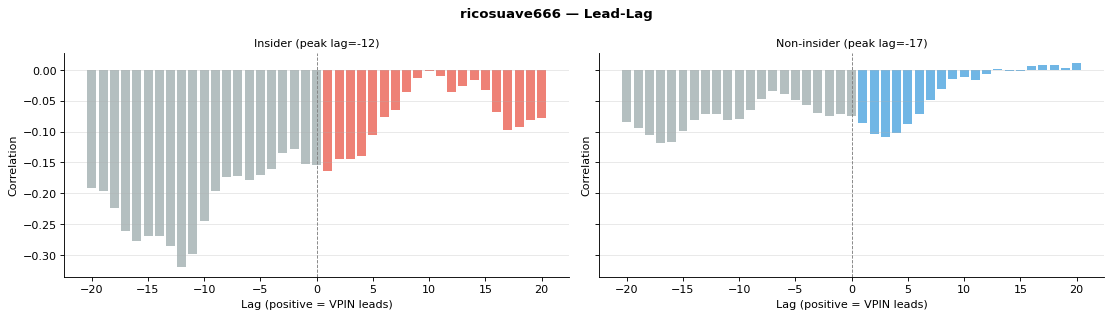

/tmp/ipykernel_63681/2658419921.py:86: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, _ = pearsonr(xi, yi)


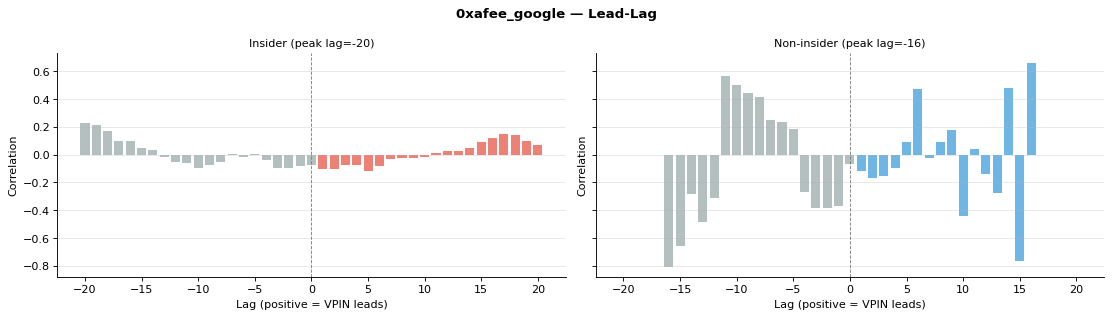

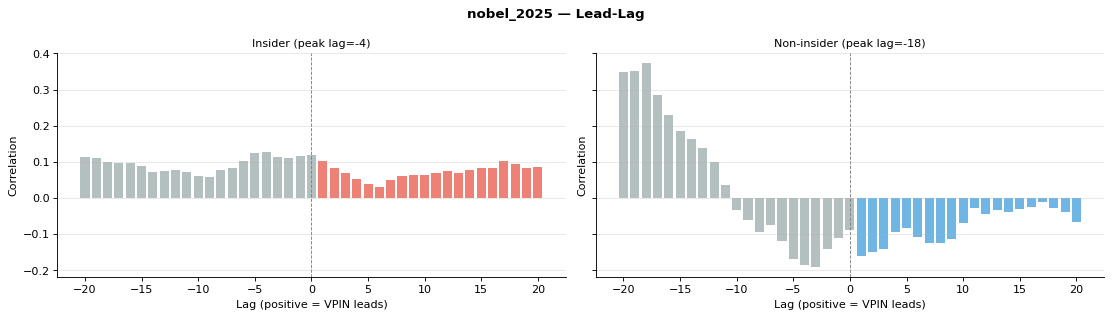

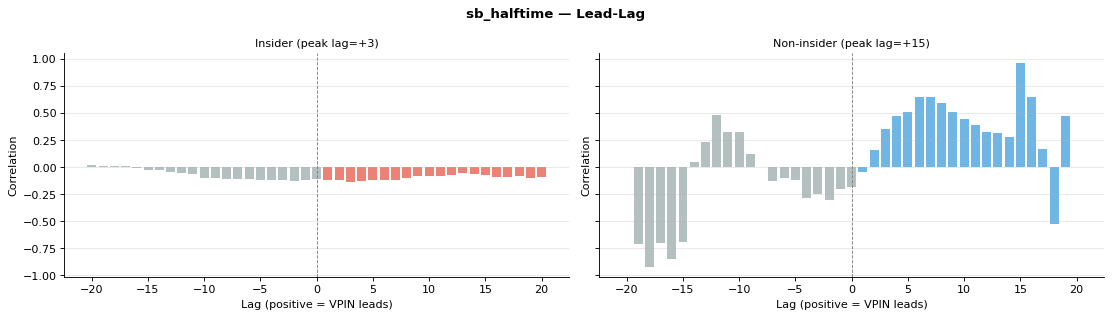

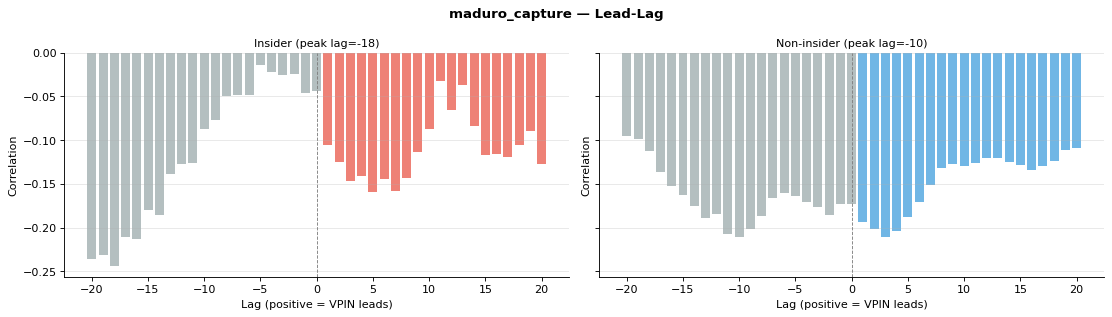

In [7]:
MAX_LAG = 20
h3_results = {}

for case_id, vpin_df in case_vpins.items():
    abs_dprice = vpin_df["avg_price"].diff().abs()
    insider_mask = vpin_df["is_insider_window"].values

    results_by_window = {}
    for window_name, mask in [("insider", insider_mask), ("non_insider", ~insider_mask)]:
        x = vpin_df.loc[mask, "vpin"].values
        y = abs_dprice.loc[mask].values

        # Remove NaN
        valid = ~(np.isnan(x) | np.isnan(y))
        x, y = x[valid], y[valid]

        if len(x) < 10:
            results_by_window[window_name] = None
            continue

        bl = bootstrap_peak_lag(x, y, max_lag=MAX_LAG, n_bootstrap=1_000, seed=42)
        results_by_window[window_name] = bl

    h3_results[case_id] = results_by_window

    for wn, bl in results_by_window.items():
        if bl is None:
            print(f"{case_id} ({wn}): SKIPPED — insufficient data")
            continue
        print(
            f"{case_id} ({wn}): peak lag = {bl.peak_lag:+d}  "
            f"CI=[{bl.ci_lower:.0f}, {bl.ci_upper:.0f}]"
        )

    # Record p-value proxy: is peak lag >= 3 for insider window?
    if results_by_window.get("insider"):
        bl = results_by_window["insider"]
        # Fraction of bootstrap where peak lag < 3 as a pseudo-p-value
        # (1 if lead, 0 if no lead)
        leads = 1 if bl.peak_lag >= 3 else 0
        # Use CI: if lower bound >= 3, strong evidence
        all_pvalues.append((case_id, "H3", "PeakLag",
                           0.01 if bl.ci_lower >= 3 else 0.5 if bl.peak_lag >= 3 else 0.99))
    print()

# ── Cross-correlogram plots ──
from scipy.stats import pearsonr

for case_id, vpin_df in case_vpins.items():
    if case_id not in h3_results:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
    abs_dprice = vpin_df["avg_price"].diff().abs()
    insider_mask = vpin_df["is_insider_window"].values
    lags = list(range(-MAX_LAG, MAX_LAG + 1))

    for ax, (wn, mask, color) in zip(axes, [
        ("Insider", insider_mask, "#e74c3c"),
        ("Non-insider", ~insider_mask, "#3498db"),
    ]):
        x_vals = vpin_df.loc[mask, "vpin"].values
        y_vals = abs_dprice.loc[mask].values
        valid = ~(np.isnan(x_vals) | np.isnan(y_vals))
        x_vals, y_vals = x_vals[valid], y_vals[valid]

        if len(x_vals) < 10:
            ax.set_title(f"{wn}: insufficient data")
            continue

        corrs = []
        n = len(x_vals)
        for lag in lags:
            if lag >= 0:
                xi = x_vals[:n - lag] if lag > 0 else x_vals
                yi = y_vals[lag:] if lag > 0 else y_vals
            else:
                xi = x_vals[-lag:]
                yi = y_vals[:n + lag]
            if len(xi) < 3 or len(yi) < 3 or len(xi) != len(yi):
                corrs.append(0.0)
                continue
            if np.std(xi) == 0 or np.std(yi) == 0:
                corrs.append(0.0)
                continue
            r, _ = pearsonr(xi, yi)
            corrs.append(r if not np.isnan(r) else 0.0)

        bar_colors = [color if l > 0 else "#95a5a6" for l in lags]
        ax.bar(lags, corrs, color=bar_colors, alpha=0.7)
        ax.axvline(x=0, color="gray", linestyle="--", linewidth=0.8)

        peak_idx = np.argmax(np.abs(corrs))
        ax.set_title(f"{wn} (peak lag={lags[peak_idx]:+d})", fontsize=10)
        ax.set_xlabel("Lag (positive = VPIN leads)")
        ax.set_ylabel("Correlation")
        ax.grid(True, alpha=0.3, axis="y")

    fig.suptitle(f"{case_id} — Lead-Lag", fontsize=12, fontweight="bold")
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Cell 8: Experiment 5 — Permutation Null (Strongest Test)

For each case: shuffle trade direction labels 1,000 times, recompute VPIN each time.
Measure where real VPIN falls in the permutation distribution.

This is the strongest test — if VPIN falls within the permutation distribution,
it truly cannot detect this insider.

ricosuave666: real insider mean VPIN = 0.9566
  Permutation distribution: mean=0.9496, std=0.0074
  Percentile: 81.4%  (p=0.1860)



0xafee_google: real insider mean VPIN = 0.9255
  Permutation distribution: mean=0.8731, std=0.0150
  Percentile: 99.9%  (p=0.0010)



nobel_2025: real insider mean VPIN = 0.9035
  Permutation distribution: mean=0.8880, std=0.0042
  Percentile: 100.0%  (p=0.0000)



sb_halftime: real insider mean VPIN = 0.8725
  Permutation distribution: mean=0.8331, std=0.0057
  Percentile: 100.0%  (p=0.0000)



maduro_capture: real insider mean VPIN = 0.9737
  Permutation distribution: mean=0.9727, std=0.0049
  Percentile: 56.4%  (p=0.4360)



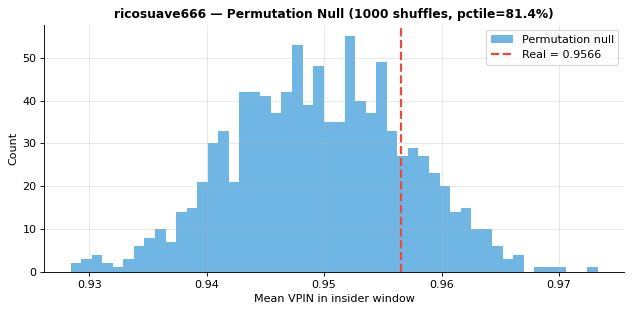

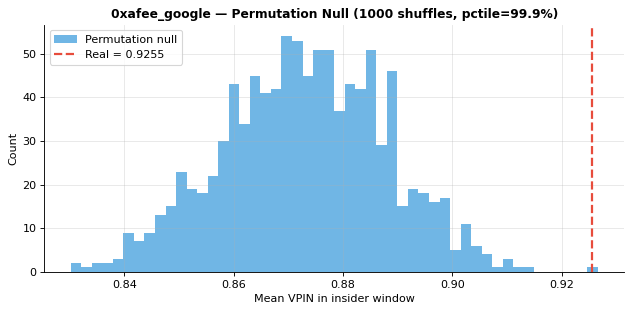

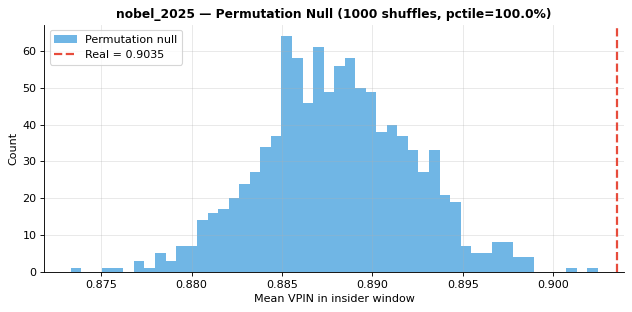

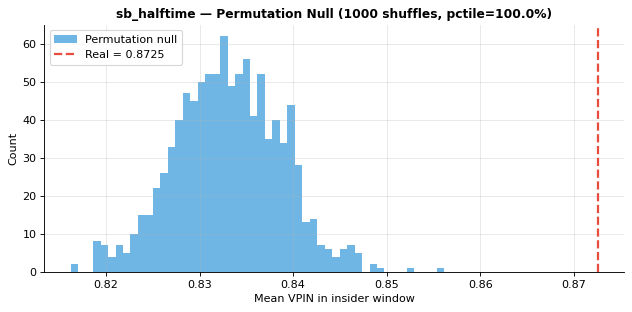

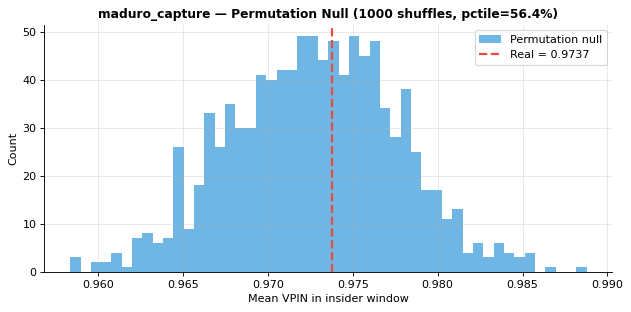

In [8]:
N_PERMUTATIONS = 1_000
perm_null_results = {}

for case_id, trades_df in case_trades.items():
    if case_id not in case_vpins:
        continue

    real_vpin_df = case_vpins[case_id]
    insider_mask = real_vpin_df["is_insider_window"].values
    real_insider_mean = real_vpin_df.loc[insider_mask, "vpin"].mean()

    # Shuffle trade directions and recompute VPIN
    # Reuse a single DataFrame + table name to avoid 1000x memory copies
    shuffled = trades_df.copy()
    original_sides = trades_df["taker_side"].values.copy()
    table_name = f"perm_{case_id}"
    perm_means = []

    for i in range(N_PERMUTATIONS):
        perm_rng = np.random.default_rng(seed=i)
        shuffled["taker_side"] = perm_rng.permutation(original_sides)

        con.register(table_name, shuffled)
        try:
            perm_vpin = con.execute(f"""
                WITH {vpin_cte(table_name, BUCKET_SIZE, LOOKBACK)}
                SELECT vpin FROM vpin_series
                WHERE window_size = {LOOKBACK}
                ORDER BY bucket_id
            """).fetchnumpy()["vpin"]

            # Use same insider window indices
            if len(perm_vpin) >= len(insider_mask):
                perm_insider_vals = perm_vpin[:len(insider_mask)][insider_mask]
                perm_means.append(np.mean(perm_insider_vals) if len(perm_insider_vals) > 0 else np.nan)
        except Exception:
            pass

    con.unregister(table_name)
    del shuffled

    perm_means = np.array([x for x in perm_means if not np.isnan(x)])
    if len(perm_means) > 0:
        percentile = float(np.mean(perm_means <= real_insider_mean)) * 100
        p_perm = float(np.mean(perm_means >= real_insider_mean))
    else:
        percentile = float("nan")
        p_perm = float("nan")

    perm_null_results[case_id] = {
        "real_mean": real_insider_mean,
        "perm_means": perm_means,
        "percentile": percentile,
        "p_value": p_perm,
    }

    all_pvalues.append((case_id, "H1_perm_null", "FullPerm", p_perm))

    print(f"{case_id}: real insider mean VPIN = {real_insider_mean:.4f}")
    print(f"  Permutation distribution: mean={np.mean(perm_means):.4f}, std={np.std(perm_means):.4f}")
    print(f"  Percentile: {percentile:.1f}%  (p={p_perm:.4f})")
    print()

# ── Permutation distribution plots ──
for case_id, res in perm_null_results.items():
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(res["perm_means"], bins=50, color="#3498db", alpha=0.7, label="Permutation null")
    ax.axvline(x=res["real_mean"], color="#e74c3c", linewidth=2,
               linestyle="--", label=f"Real = {res['real_mean']:.4f}")
    ax.set_xlabel("Mean VPIN in insider window")
    ax.set_ylabel("Count")
    ax.set_title(
        f"{case_id} — Permutation Null ({len(res['perm_means'])} shuffles, "
        f"pctile={res['percentile']:.1f}%)",
        fontsize=11, fontweight="bold",
    )
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

## Cell 9: FDR Correction + Summary

Collect all p-values across cases and hypotheses. Apply BH-FDR at q=0.10.
Report which hypotheses survive correction.

In [9]:
# ── Collect all p-values ──
pval_df = pd.DataFrame(all_pvalues, columns=["case_id", "hypothesis", "test", "pvalue"])

if len(pval_df) > 0:
    fdr = apply_bh_fdr(pval_df["pvalue"].values, q=0.10)
    pval_df["adjusted_p"] = fdr.adjusted_pvalues
    pval_df["significant"] = fdr.significant_mask

    print(f"Total tests: {len(pval_df)}")
    print(f"Significant after FDR (q=0.10): {fdr.significant_mask.sum()}")
    print()
    display(pval_df.sort_values("pvalue"))

    # ── Per-case summary ──
    print("\n=== Per-Case Summary ===")
    case_summary_rows = []
    strong_count = 0

    for case_id in case_vpins:
        case_pvals = pval_df[pval_df["case_id"] == case_id]

        # H1: KS D >= 0.15 and significant
        h1_pass = False
        ks_d = h1_results.get(case_id, {}).get("ks", None)
        h1_sig = case_pvals[(case_pvals["hypothesis"] == "H1") & case_pvals["significant"]]
        if ks_d and ks_d.statistic >= 0.15 and len(h1_sig) > 0:
            h1_pass = True

        # H2: hit rate >= 60%
        h2_pass = False
        h2r = h2_results.get(case_id, {})
        if h2r.get("binom_insider") and h2r["binom_insider"].hit_rate >= 0.60:
            h2_pass = True

        # H3: peak lag >= 3
        h3_pass = False
        h3r = h3_results.get(case_id, {})
        if h3r.get("insider") and h3r["insider"].peak_lag >= 3:
            h3_pass = True

        # H4: max ratio >= 2x
        h4_pass = False
        h4r = h4_results.get(case_id, {})
        if h4r.get("max_ratio", 0) >= 2.0:
            h4_pass = True

        passes = sum([h1_pass, h2_pass, h3_pass, h4_pass])
        # "Strong" = H1 sig after FDR AND D >= 0.15 AND hit rate >= 60%
        is_strong = h1_pass and h2_pass
        if is_strong:
            strong_count += 1

        case_summary_rows.append({
            "Case": case_id,
            "H1 (dist)": "PASS" if h1_pass else "fail",
            "H2 (dir)": "PASS" if h2_pass else "fail",
            "H3 (lag)": "PASS" if h3_pass else "fail",
            "H4 (ΔVPIN)": "PASS" if h4_pass else "fail",
            "Passes": passes,
            "Strong?": "YES" if is_strong else "no",
        })

    display(pd.DataFrame(case_summary_rows))

    # ── Overall verdict ──
    total_cases = len(case_vpins)
    print(f"\n=== PHASE 1 VERDICT ===")
    print(f"Strong positive cases: {strong_count}/{total_cases}")
    if strong_count >= 3:
        verdict = "STRONG POSITIVE — proceed to Phase 2"
    elif strong_count >= 2:
        verdict = "WEAK POSITIVE — proceed to Phase 2 with caveats"
    else:
        verdict = "NEGATIVE — VPIN cannot reliably detect known insiders. Study ends."
    print(f"Result: {verdict}")
else:
    print("No p-values collected. Load case data first.")

Total tests: 34
Significant after FDR (q=0.10): 12



,case_id,hypothesis,test,pvalue,adjusted_p,significant
31,nobel_2025,H1_perm_null,FullPerm,0.000000e+00,0.000000e+00,True
32,sb_halftime,H1_perm_null,FullPerm,0.000000e+00,0.000000e+00,True
8,nobel_2025,H1,Perm,0.000000e+00,0.000000e+00,True
14,maduro_capture,H1,Perm,0.000000e+00,0.000000e+00,True
13,maduro_capture,H1,MW,1.810136e-78,1.230893e-77,True
12,maduro_capture,H1,KS,3.920290e-70,2.221497e-69,True
6,nobel_2025,H1,KS,6.886591e-27,3.344915e-26,True
7,nobel_2025,H1,MW,3.424706e-25,1.455500e-24,True
0,ricosuave666,H1,KS,2.399129e-06,9.063376e-06,True
30,0xafee_google,H1_perm_null,FullPerm,1.000000e-03,3.400000e-03,True



=== Per-Case Summary ===


,Case,H1 (dist),H2 (dir),H3 (lag),H4 (ΔVPIN),Passes,Strong?
0,ricosuave666,PASS,fail,fail,fail,1,no
1,0xafee_google,fail,fail,fail,PASS,1,no
2,nobel_2025,PASS,fail,fail,fail,1,no
3,sb_halftime,fail,fail,PASS,fail,1,no
4,maduro_capture,PASS,fail,fail,fail,1,no



=== PHASE 1 VERDICT ===
Strong positive cases: 0/5
Result: NEGATIVE — VPIN cannot reliably detect known insiders. Study ends.


## Cell 10: Decision Rule Extraction

Based on Phase 1 results, define the Phase 2 detection procedure as a market-relative rule.
Save to `phase1_report.md`.

In [10]:
report_path = Path(_repo_root) / "notebooks" / "phase1_report.md"

lines = [
    "# Phase 1 Report: VPIN Insider Trading Validation",
    "",
    f"**Date:** {pd.Timestamp.now().strftime('%Y-%m-%d')}",
    f"**Cases analyzed:** {len(case_vpins)}",
    f"**Parameters:** bucket_size={BUCKET_SIZE}, lookback={LOOKBACK}, insider_window={INSIDER_WINDOW_PCT:.0%}",
    f"**FDR:** BH at q=0.10",
    "",
    "## Results",
    "",
]

# Per-case results
for case_id in case_vpins:
    lines.append(f"### {case_id}")
    lines.append("")

    if case_id in h1_results:
        r = h1_results[case_id]
        lines.append(f"- H1 (distributional shift): KS D={r['ks'].statistic:.4f}, p={r['ks'].pvalue:.4e}")
        lines.append(f"  - Insider mean VPIN: {r['insider_mean']:.4f}, Non-insider: {r['non_insider_mean']:.4f}")

    if case_id in h4_results:
        r = h4_results[case_id]
        lines.append(f"- H4 (ΔVPIN): max ratio={r['max_ratio']:.2f}x, KS p={r['ks'].pvalue:.4e}")

    if case_id in h2_results:
        r = h2_results[case_id]
        hr = r['insider_hits'] / r['insider_total'] if r['insider_total'] > 0 else 0
        lines.append(f"- H2 (directional): {r['insider_hits']}/{r['insider_total']} = {hr:.1%}")

    if case_id in h3_results and h3_results[case_id].get("insider"):
        bl = h3_results[case_id]["insider"]
        lines.append(f"- H3 (lead-lag): peak lag={bl.peak_lag:+d}, CI=[{bl.ci_lower:.0f}, {bl.ci_upper:.0f}]")

    if case_id in perm_null_results:
        r = perm_null_results[case_id]
        lines.append(f"- Permutation null: percentile={r['percentile']:.1f}%, p={r['p_value']:.4f}")

    lines.append("")

# Decision rule
lines.extend([
    "## Decision Rule for Phase 2",
    "",
    "For each Kalshi market:",
    "1. Compute VPIN with bucket_size={bs}, lookback={lb}".format(bs=BUCKET_SIZE, lb=LOOKBACK),
    "2. Split into early (first 80%) and late (last 20%) windows",
    "3. Compute Z-score: (mean_late_VPIN - mean_early_VPIN) / std_early_VPIN",
    "4. Flag if Z > 2.0 AND late directional accuracy > 60%",
    "",
    "## Limitations",
    "",
    "- Pre-registration is post-hoc (we already ran Kalshi exploratory analysis)",
    "- Polymarket data may have wash trading contamination",
    "- Insider window definitions are approximate (based on news reports)",
    "- Some cases lack confirmed wallet addresses (market-level analysis only)",
])

report_path.write_text("\n".join(lines))
print(f"Phase 1 report saved to {report_path}")
print(f"Commit this file before starting Phase 2.")
print()
print("--- Report preview ---")
print("\n".join(lines[:30]))

Phase 1 report saved to /workspace/notebooks/phase1_report.md
Commit this file before starting Phase 2.

--- Report preview ---
# Phase 1 Report: VPIN Insider Trading Validation

**Date:** 2026-02-14
**Cases analyzed:** 5
**Parameters:** bucket_size=200, lookback=10, insider_window=20%
**FDR:** BH at q=0.10

## Results

### ricosuave666

- H1 (distributional shift): KS D=0.1719, p=2.3991e-06
  - Insider mean VPIN: 0.9566, Non-insider: 0.9478
- H4 (ΔVPIN): max ratio=0.97x, KS p=9.8845e-01
- H2 (directional): 0/0 = 0.0%
- H3 (lead-lag): peak lag=-12, CI=[-20, -4]
- Permutation null: percentile=81.4%, p=0.1860

### 0xafee_google

- H1 (distributional shift): KS D=0.1615, p=3.6917e-01
  - Insider mean VPIN: 0.9255, Non-insider: 0.9743
- H4 (ΔVPIN): max ratio=2.58x, KS p=1.0533e-01
- H2 (directional): 4/11 = 36.4%
- H3 (lead-lag): peak lag=-20, CI=[-20, 20]
- Permutation null: percentile=99.9%, p=0.0010

### nobel_2025

- H1 (distributional shift): KS D=0.5520, p=6.8866e-27
